# Colon Cancer Tissue Microarray Classification

This notebook is the **classifier phase** of the pipeline. It consumes the sample-by-gene expression tables produced by the R preprocessing phase (fRMA normalization, probe-to-gene mapping, quantile normalization, ComBat batch correction) and asks one question: **can a model tell cancerous tissue from healthy tissue from its gene-expression profile?** It trains seven classifiers and compares them.

One toggle, `HELD_OUT_GSE`, selects the run mode:

- `HELD_OUT_GSE = None` — **complete run**: pool every colon GSE and score each model by cross-validated accuracy. Answers "how well does this work in general?"
- `HELD_OUT_GSE = "<GSE>"` — **leave-one-out (LOO) run**: train on all GSEs *except* one and test on the held-out GSE. Answers the harder question "does this generalize to a study the model has never seen?" A more realistic deployment scenario, since batch effects between studies make cross-study prediction much harder than within-study cross-validation.

Sample labels (cancer = 1, healthy = 0) are built from `colon_labels.json`. See *Data prep* for how. Everything after the config file is identical across all three cancer types; only the config and the `.dat` tables differ.

In [1]:
# Optional: Intel extension that accelerates scikit-learn model training
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
except Exception:
    pass # Skip if not installed

## Run configuration

Set `HELD_OUT_GSE` to choose the mode. In LOO mode it must be one of the GSE numbers in the config, as a string (e.g. `'23878'`). The notebook then reads the matching `.dat`
table(s) written by `preprocess.R`: `{prefix}.dat` for a complete run, or `{prefix}_loo{GSE}_train.dat` / `_test.dat` for a LOO run. `ITERS` is how many random subsamples are averaged per training-size increment in LOO mode.

In [20]:
# === Run mode ===
# None         -> complete run (all GSEs trained/evaluated together)
# a GSE string -> leave-one-out run (that GSE becomes the held-out test set)
HELD_OUT_GSE = None

CONFIG_PATH = 'colon_labels.json'   # label config for this cancer type
BASE_DIR    = '.'                    # directory holding the .txt and .dat files
ITERS       = 50                     # iterations averaged per increment (LOO mode)

## Imports

The Keras backend is selected here. Defaults to PyTorch; change it to match your install (see *Keras backend* in the README for more information).

In [21]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # make classifier_utils.py (repo root) importable
os.environ['KERAS_BACKEND'] = 'torch'        # Keras 3 backend; set before importing keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
import xgboost as xgb

import classifier_utils as cu

## Data prep — load expression table and build labels

Each row of a `.dat` table is one tissue sample; each column is one gene's normalized expression. The matching label array (cancer = 1, healthy = 0) is built from the JSON config, which records, per GSE, in the same row order as the table, how that study's samples are labeled. A label block is one of four kinds:

- uniform: every sample in the GSE shares one label;
- blocks: contiguous runs of one label then another (e.g. 17 healthy, then 104 cancer);
- alternating: labels alternate sample by sample;
- text: labels are parsed from a per-GSE `.txt` file by matching a keyword in each sample's description.

`build_labels` concatenates these blocks in config order. The assertion that the label count equals the table's row count prevents any drift between the config and the preprocessed data. In LOO mode the held-out GSE's block becomes the test labels (and is removed from the training labels), and its table is loaded separately as the test set.

In [22]:
CONFIG   = cu.load_config(CONFIG_PATH)
COMPLETE = HELD_OUT_GSE is None
paths    = cu.dat_paths(CONFIG, BASE_DIR, HELD_OUT_GSE)

train_labels, test_labels = cu.build_labels(CONFIG, BASE_DIR, HELD_OUT_GSE)

if COMPLETE:
    train_df, _ = cu.load_dat(paths['complete'])
    test_df = None
else:
    train_df, _ = cu.load_dat(paths['train'])
    test_df, _  = cu.load_dat(paths['test'])

# Assert that a label array matches the table row count; otherwise, the config
# and the preprocessed data do not match
assert len(train_df) == len(train_labels), (len(train_df), len(train_labels))
if test_df is not None:
    assert len(test_df) == len(test_labels), (len(test_df), len(test_labels))

print('mode:', 'complete' if COMPLETE else f'leave-one-out (held out GSE{HELD_OUT_GSE})')
print('train samples:', len(train_df), '| features:', train_df.shape[1])
if test_df is not None:
    print('test samples:', len(test_df))

mode: leave-one-out (held out GSE23878)
train samples: 326 | features: 19297
test samples: 59


## Feature selection

The tables have ~19,000 genes but only a few hundred samples. Most of these genes are noise and have little predictive power, and keeping such a large number of features can cause models to overfit easily. Feature selection cuts the gene set down to a small, informative subset which is what the models are allowed to see. Two subset sizes (50 and 20 genes) are used so models can be compared using both; the 300-gene set is just an intermediate. The steps are as follows:

1. Remove redundant correlated features (`cu.select_uncorrelated`): build the absolute correlation matrix, treat each connected component of the abs(corr) > 0.85 graph as a cluster of mutually redundant genes, and keep the single member most correlated with the label, dropping the rest.
2. Coarse filter to 300: based on a Random Forest estimator, keep the 300 features with the highest importances.
3. Fine RFE to 50, then 20: one-gene-at-a-time recursive elimination.

The 300-feature set is an intermediate; only the 50- and 20-feature sets feed the classifiers. The Random Forest used here is for feature selection only and is separate from the Random Forest classifier evaluated later. All selection is computed on the training set, so it stays leak-free in leave-one-out mode.

In [23]:
# 1. Remove redundant correlated features. The kept member of each correlated
# group is the one most associated with the label.
keep_cols, to_drop = cu.select_uncorrelated(train_df, train_labels, threshold=0.85)
train_df = train_df[keep_cols]
if test_df is not None:
    test_df = test_df[keep_cols]
print('dropped', len(to_drop), 'redundant features;', train_df.shape[1], 'remain')

dropped 940 redundant features; 18357 remain


In [24]:
# 2. Coarse filter: one Random Forest fit, keep the top 300 features by
# importance.
fs_rf = RandomForestClassifier(n_jobs=-1).fit(train_df, train_labels)
top300 = train_df.columns[np.argsort(fs_rf.feature_importances_)[-300:]]
tr300 = train_df[top300]
te300 = test_df[top300] if test_df is not None else None

# 3. Fine RFE: 300 -> 50 -> 20
rfe50 = RFE(estimator=RandomForestClassifier(n_jobs=-1), n_features_to_select=50).fit(tr300, train_labels)
tr50  = tr300.loc[:, rfe50.support_]
te50  = te300.loc[:, rfe50.support_] if te300 is not None else None

rfe20 = RFE(estimator=RandomForestClassifier(n_jobs=-1), n_features_to_select=20).fit(tr50, train_labels)
tr20  = tr50.loc[:, rfe20.support_]
te20  = te50.loc[:, rfe20.support_] if te50 is not None else None

# Convenience arrays used by every model below.
X20, X50 = np.array(tr20), np.array(tr50)
y = train_labels
if test_df is not None:
    Xt20, Xt50 = np.array(te20), np.array(te50)
print('feature sets ready: X20', X20.shape, '| X50', X50.shape)

feature sets ready: X20 (326, 20) | X50 (326, 50)


# Complete-run model evaluation

Complete mode runs only when `HELD_OUT_GSE = None`. Each of the GSE datasets are combined into one large dataset, and each model is scored by 5-fold stratified cross-validated accuracy on both the 20- and 50-feature sets. Models with a single defining hyperparameter (tree depth, neighbor count, etc.) are iterated over a range, and the best score is kept. Results here are generally expected to be optimistic since train and test samples are drawn from the same pooled studies. The LOO section is the more difficult and more realistic test.

In [7]:
# Accuracy summary, filled in by the model cells below.
complete_acc = {}

## Decision tree

A tree of expressions that evaluate to true/false in each internal node, which dictates branch traversal. It is simple to interpret but prone to overfitting, so `max_depth` is iterated and the best cross-validated depth is presented. Ensemble methods generally should perform better than this type of model.

In [8]:
if COMPLETE:
    dt20 = [np.mean(cross_val_score(make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=d)),
                                    X20, y, cv=StratifiedKFold(), n_jobs=-1)) for d in range(2, 20)]
    dt50 = [np.mean(cross_val_score(make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=d)),
                                    X50, y, cv=StratifiedKFold(), n_jobs=-1)) for d in range(2, 20)]
    print('20-feat acc by max_depth(2..19):', np.round(dt20, 4))
    print('50-feat acc by max_depth(2..19):', np.round(dt50, 4))
    complete_acc['Decision Tree'] = {'20': max(dt20), '50': max(dt50)}

20-feat acc by max_depth(2..19): [0.8494 0.8468 0.8571 0.8753 0.8909 0.8494 0.8935 0.8831 0.8831 0.8468
 0.8468 0.8857 0.8442 0.8519 0.8883 0.8909 0.8571 0.8494]
50-feat acc by max_depth(2..19): [0.8494 0.8494 0.8571 0.8442 0.8883 0.8519 0.8909 0.8909 0.8909 0.8545
 0.8883 0.8987 0.8987 0.8545 0.8519 0.8545 0.8494 0.8597]


## Random forest

An ensemble of decision trees whose votes are tabulated, which helps control a single tree's overfitting and handles noisy, high-dimensional gene data well. It is a strong, low-effort baseline.

In [9]:
if COMPLETE:
    rf20 = [np.mean(cross_val_score(make_pipeline(StandardScaler(), RandomForestClassifier(max_depth=d)),
                                    X20, y, cv=StratifiedKFold(), n_jobs=-1)) for d in range(2, 20)]
    rf50 = [np.mean(cross_val_score(make_pipeline(StandardScaler(), RandomForestClassifier(max_depth=d)),
                                    X50, y, cv=StratifiedKFold(), n_jobs=-1)) for d in range(2, 20)]
    print('20-feat acc by max_depth(2..19):', np.round(rf20, 4))
    print('50-feat acc by max_depth(2..19):', np.round(rf50, 4))
    complete_acc['Random Forest'] = {'20': max(rf20), '50': max(rf50)}

20-feat acc by max_depth(2..19): [0.9091 0.9273 0.9117 0.9169 0.9195 0.9169 0.9273 0.9221 0.9143 0.9169
 0.9195 0.9221 0.9143 0.9169 0.9143 0.9221 0.9221 0.9247]
50-feat acc by max_depth(2..19): [0.9091 0.9299 0.9169 0.9351 0.9247 0.9325 0.9221 0.9247 0.9325 0.9221
 0.9325 0.9351 0.9325 0.9195 0.9195 0.9247 0.9325 0.9455]


## Support vector machine

Maximizes the margin boundary between classes. SVMs are an effective when using data with relatively few samples, especially compared to the number of features, such as the genomic microarray data used here. `C` and `gamma` are grid-searched.

In [10]:
if COMPLETE:
    def _svm_cv(X):
        grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1e-4, 1e-3, 1e-2, 1e-1]}
        Xs = StandardScaler().fit_transform(X)
        best = GridSearchCV(SVC(), grid, cv=3, n_jobs=-1).fit(Xs, y).best_params_
        acc = np.mean(cross_val_score(make_pipeline(StandardScaler(), SVC(**best)),
                                      X, y, cv=StratifiedKFold(), n_jobs=-1))
        return best, acc
    b20, svm20 = _svm_cv(X20)
    b50, svm50 = _svm_cv(X50)
    print('20-feat best', b20, '-> acc', round(svm20, 4))
    print('50-feat best', b50, '-> acc', round(svm50, 4))
    complete_acc['SVM'] = {'20': svm20, '50': svm50}

20-feat best {'C': 10, 'gamma': 0.1} -> acc 0.9325
50-feat best {'C': 10, 'gamma': 0.01} -> acc 0.9403


## XGBoost

Gradient-boosted decision trees. The workflow involves adding more trees sequentially, each training on the loss values of the last, with regularization. It often performs better than Random Forest and is included here for a comparison. `max_depth` is iterated.

In [11]:
if COMPLETE:
    xgb20 = [np.mean(cross_val_score(make_pipeline(StandardScaler(),
                 xgb.XGBClassifier(n_estimators=100, objective='binary:logistic', max_depth=d)),
                 X20, y, cv=StratifiedKFold(), n_jobs=-1)) for d in range(2, 20)]
    xgb50 = [np.mean(cross_val_score(make_pipeline(StandardScaler(),
                 xgb.XGBClassifier(n_estimators=100, objective='binary:logistic', max_depth=d)),
                 X50, y, cv=StratifiedKFold(), n_jobs=-1)) for d in range(2, 20)]
    print('20-feat acc by max_depth(2..19):', np.round(xgb20, 4))
    print('50-feat acc by max_depth(2..19):', np.round(xgb50, 4))
    complete_acc['XGBoost'] = {'20': max(xgb20), '50': max(xgb50)}

20-feat acc by max_depth(2..19): [0.9143 0.9039 0.8987 0.8987 0.8987 0.8987 0.8987 0.8987 0.8987 0.8987
 0.8987 0.8987 0.8987 0.8987 0.8987 0.8987 0.8987 0.8987]
50-feat acc by max_depth(2..19): [0.9247 0.8909 0.8883 0.8857 0.8883 0.8909 0.8935 0.8935 0.8935 0.8935
 0.8935 0.8935 0.8935 0.8935 0.8935 0.8935 0.8935 0.8935]


## K-nearest neighbors

Classifies a sample by the majority label among the `k` samples closest to it in feature space. This type of model usually requires fewer features and normalized values to perform well. `k` is iterated.

In [12]:
if COMPLETE:
    knn20 = [np.mean(cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                                     X20, y, cv=StratifiedKFold(), n_jobs=-1)) for k in range(1, 20)]
    knn50 = [np.mean(cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                                     X50, y, cv=StratifiedKFold(), n_jobs=-1)) for k in range(1, 20)]
    print('20-feat acc by k(1..19):', np.round(knn20, 4))
    print('50-feat acc by k(1..19):', np.round(knn50, 4))
    complete_acc['KNN'] = {'20': max(knn20), '50': max(knn50)}

20-feat acc by k(1..19): [0.9377 0.8364 0.8857 0.8468 0.8675 0.8312 0.8623 0.839  0.8649 0.839
 0.8494 0.8442 0.8468 0.8286 0.8338 0.8208 0.826  0.8156 0.8208]
50-feat acc by k(1..19): [0.9429 0.8623 0.9195 0.8753 0.8857 0.8545 0.8675 0.839  0.8468 0.8208
 0.8416 0.8104 0.8338 0.813  0.8338 0.8078 0.8234 0.8078 0.8104]


## Multi-layer perceptron (with Keras Tuner)

A feed-forward neural network, included to test whether a model that learns nonlinear combinations of genes performs better than the simpler classifiers on these small datasets. A Hyperband search tunes the architecture (1-3 hidden layers, 8-128 units each, dropout, learning rate) in a tournament-style fashion; the best model is trained and its training/validation accuracy and loss are plotted against epoch. The 'knee' of the curve is typically the epoch that performs the best, as earlier epochs are usually underfit while later epochs (especially where the training and validation accuracy curves begin to diverge) are overfit. Accuracy is then estimated by k-fold cross-validation.

The 20- and 50-feature runs are divided into separate cells since Keras Tuner clears its cell's output during the search, which clobbers the output metrics and graphs displayed previously.

In [13]:
import keras_tuner as kt
import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam

def make_build_model(n_features):
    """Return a Keras-Tuner build function for an input of n_features."""
    def build_model(hp):
        model = Sequential()
        model.add(Input(shape=(n_features,)))
        for i in range(hp.Int('layers', 1, 3)):
            model.add(Dense(units=hp.Int('units_' + str(i), min_value=8, max_value=128, step=4)))
            model.add(BatchNormalization())
            model.add(Activation('relu'))
            model.add(Dropout(hp.Choice('drop_' + str(i), values=[.0, .1, .2, .3])))
        model.add(Dense(1))
        model.add(BatchNormalization())
        model.add(Activation('sigmoid'))
        lr = hp.Choice('learning_rate', values=[.01, .001, .0001])
        model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['accuracy'])
        return model
    return build_model

In [14]:
def run_mlp_complete(X, n_features, kt_dir):
    """Tune + train an MLP, plot accuracy/loss vs epoch, return CV accuracy."""
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=.2)
    ss = StandardScaler().fit(X_tr)
    tuner = kt.Hyperband(make_build_model(n_features), objective='val_accuracy',
                         max_epochs=20, factor=3, directory=kt_dir, overwrite=False)
    stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
    tuner.search(ss.transform(X_tr), y_tr, epochs=50, validation_split=.2, callbacks=[stop_early])
    best_hps = tuner.get_best_hyperparameters(num_trials=3)[0]

    # Pick an epoch count (floored at 20, as in the original notebook).
    probe = tuner.hypermodel.build(best_hps)
    hist = probe.fit(ss.transform(X_tr), y_tr, epochs=50, validation_split=.2, verbose=0)
    best_epoch = max(int(np.argmax(hist.history['val_accuracy'])) + 1, 20)

    # Retrain and plot training/validation accuracy & loss vs epoch.
    model = tuner.hypermodel.build(best_hps)
    hist = model.fit(ss.transform(X_tr), y_tr, epochs=best_epoch, validation_split=.2, verbose=0)
    ep = range(best_epoch)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(ep, hist.history['accuracy'], label='Training Accuracy')
    plt.plot(ep, hist.history['val_accuracy'], label='Validation Accuracy')
    plt.legend(loc='lower right'); plt.title(f'MLP {n_features}-feat: Accuracy vs Epoch')
    plt.subplot(1, 2, 2)
    plt.plot(ep, hist.history['loss'], label='Training Loss')
    plt.plot(ep, hist.history['val_loss'], label='Validation Loss')
    plt.legend(loc='upper right'); plt.title(f'MLP {n_features}-feat: Loss vs Epoch')
    plt.show()

    # Cross-validated accuracy (scaler fit per fold to avoid leakage).
    accs = []
    for tr_idx, te_idx in KFold(shuffle=True).split(X, y):
        s = StandardScaler().fit(X[tr_idx])
        m = tuner.hypermodel.build(best_hps)
        m.fit(s.transform(X[tr_idx]), y[tr_idx], epochs=best_epoch, validation_split=.2, verbose=0)
        accs.append(m.evaluate(s.transform(X[te_idx]), y[te_idx], verbose=0)[1])
    return float(np.mean(accs))

Trial 30 Complete [00h 00m 01s]
val_accuracy: 0.5645161271095276

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 18s


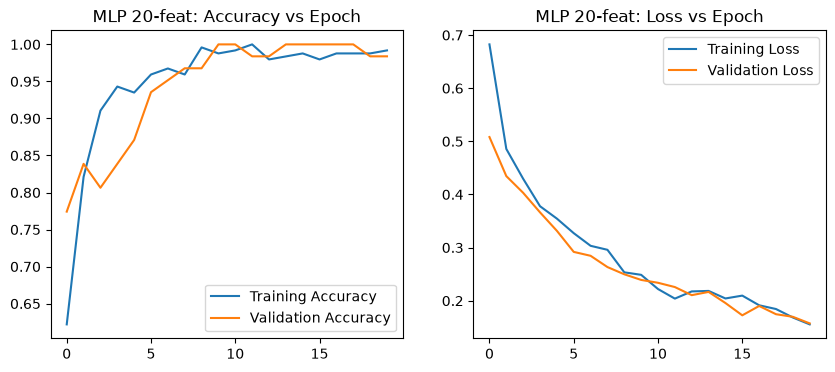

MLP accuracy 20-feat: 0.9351


In [15]:
if COMPLETE:
    cancer = CONFIG['cancer']
    mlp20 = run_mlp_complete(X20, 20, f'kt_{cancer}_complete_20')
    complete_acc.setdefault('MLP', {})['20'] = mlp20
    print('MLP accuracy 20-feat:', round(mlp20, 4))

Trial 30 Complete [00h 00m 01s]
val_accuracy: 0.9838709831237793

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 18s


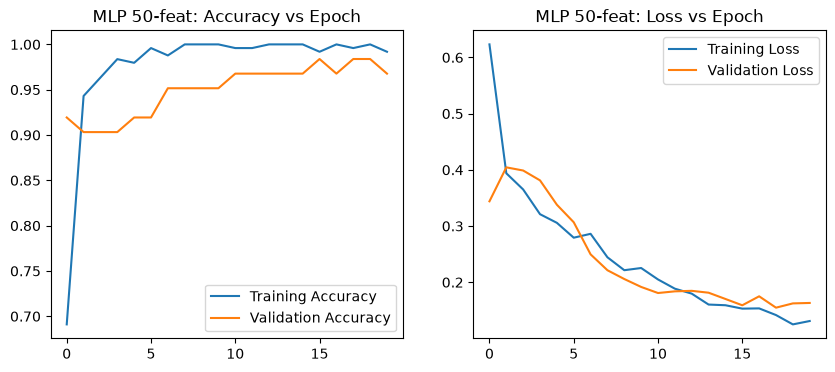

MLP accuracy 50-feat: 0.9221


In [16]:
if COMPLETE:
    cancer = CONFIG['cancer']
    mlp50 = run_mlp_complete(X50, 50, f'kt_{cancer}_complete_50')
    complete_acc.setdefault('MLP', {})['50'] = mlp50
    print('MLP accuracy 50-feat:', round(mlp50, 4))

## Logistic regression

A linear probabilistic classifier. If it performs similarly to the nonlinear models, the classes are largely linearly separable with the selected genes. A decision boundary plot is included for a visual representation. Note that for two-dimensional viewing of the decision boundary, only the two leading principal components are used to plot each sample, so the visual representation is not entirely reflective of the model's actual accuracy.

In [17]:
if COMPLETE:
    lr20 = np.mean(cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()),
                                   X20, y, cv=StratifiedKFold(), n_jobs=-1))
    lr50 = np.mean(cross_val_score(make_pipeline(StandardScaler(), LogisticRegression()),
                                   X50, y, cv=StratifiedKFold(), n_jobs=-1))
    complete_acc['Logistic Regression'] = {'20': lr20, '50': lr50}
    print('LogReg acc  20-feat:', round(lr20, 4), '| 50-feat:', round(lr50, 4))

LogReg acc  20-feat: 0.4779 | 50-feat: 0.3403


### Decision boundary

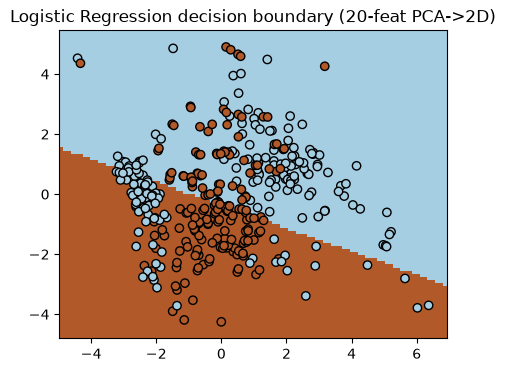

PCA explained variance ratio: [0.1918 0.1354]


In [18]:
if COMPLETE:
    ss = StandardScaler()
    pca = PCA(n_components=2)
    pca_arr = pca.fit_transform(ss.fit_transform(X20))
    lr = LogisticRegression().fit(pca_arr, y)
    _, ax = plt.subplots(figsize=(5, 4))
    DecisionBoundaryDisplay.from_estimator(
        lr, pca_arr, cmap=plt.cm.Paired, ax=ax,
        response_method='predict', plot_method='pcolormesh', shading='auto', eps=0.5)
    ax.scatter(pca_arr[:, 0], pca_arr[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title('Logistic Regression decision boundary (20-feat PCA->2D)')
    plt.show()
    print('PCA explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))

## Accuracy summary

Best cross-validated accuracy per model of the 20- vs 50-feature datasets.

In [19]:
if COMPLETE:
    order = ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost', 'KNN', 'MLP', 'Logistic Regression']
    summary = pd.DataFrame(
        {m: {'20-feat': complete_acc[m]['20'], '50-feat': complete_acc[m]['50']}
         for m in order if m in complete_acc}).T
    print('Complete-run cross-validated accuracy (best over hyperparameter sweep):')
    display(summary.round(4))

Complete-run cross-validated accuracy (best over hyperparameter sweep):


,20-feat,50-feat
Decision Tree,0.8935,0.8987
Random Forest,0.9273,0.9455
SVM,0.9325,0.9403
XGBoost,0.9143,0.9247
KNN,0.9377,0.9429
MLP,0.9351,0.9221
Logistic Regression,0.4779,0.3403


# Leave-one-out evaluation

Runs only when `HELD_OUT_GSE` is set. This is a more realistic test; the held-out GSE is an entire study the models will never see during training, so good scores here means the signal generalizes
across studies rather than memorizing only one study's batch nuances. The model trains on the remaining GSEs and is evaluated on the held-out one.

For every model, 10 training-size increments are iterated over (100% down to 10%, increments of 10%), averaging 50 iterations per increment, and record accuracy, precision, recall and F1 on the held-out test set. Measuring accuracy alone can be misleading when the classes are imbalanced, so precision, recall, and especially F1 score help show a more complete picture. The training-size iterations show how performance degrades as data shrinks. A flat curve means the model already has enough data, while a steep one means more would help. Training sets using less than 100% of the available training data are stratified, so class balance is fixed across iterations and the variability reflects model instability rather than imbalanced class ratios.

Decision Tree, Random Forest, XGBoost, and KNN tests also iterate over their main hyperparameter, giving a 4-panel metric-vs-hyperparameter plot with one line per training fraction. SVM, MLP, and Logistic Regression meanwhile give a metric-vs-training-size plot.

Random Forest, XGBoost, SVM and MLP cache trained models inside the `pkls/{cancer}_loo{GSE}/` directory, so re-runs skip retraining. Clear these directories to force retraining.

In [25]:
if not COMPLETE:
    import os, random, joblib
    from sklearn.decomposition import KernelPCA

    PERCENTS = [1, .9, .8, .7, .6, .5, .4, .3, .2, .1]
    DEPTHS   = list(range(2, 11))    # tree / XGBoost max_depth sweep
    KS       = list(range(1, 11))    # KNN neighbor sweep
    STRATIFY = True                  # hold class balance fixed across subsamples
    DIRNAME  = f"{CONFIG['cancer']}_loo{HELD_OUT_GSE}"   # cache namespace

    def run_tree_sweep(Xtr, Xte, make_est, hp_values, cache_sub=None, break_at_full=False):
        """percents x iters x hp_values -> per-increment mean/var of [acc,prec,rec,f1]."""
        means, varis = [], []
        for p in PERCENTS:
            per_iter = []
            for it in range(ITERS):
                Xs, ys = cu.subsample(Xtr, train_labels, p, STRATIFY)
                ss = StandardScaler().fit(Xs)
                Xs_s, Xte_s = ss.transform(Xs), ss.transform(Xte)
                row = []
                for hp in hp_values:
                    clf = None
                    if cache_sub is not None:
                        path = f"pkls/{DIRNAME}/{cache_sub}/train_{p*100:.0f}/iter_{it+1}/hp_{hp}.pkl"
                        if os.path.exists(path):
                            clf = joblib.load(path)
                    if clf is None:
                        clf = make_est(hp).fit(Xs_s, ys)
                        if cache_sub is not None:
                            os.makedirs(os.path.dirname(path), exist_ok=True)
                            joblib.dump(clf, path, compress=3)
                    row.append(cu.score(test_labels, clf.predict(Xte_s)))
                per_iter.append(row)
                if p >= 1 and break_at_full:   # deterministic at 100% -> one iter suffices
                    break
            arr = np.array(per_iter)           # [iters, hp, 4]
            means.append(arr.mean(axis=0))     # [hp, 4]
            varis.append(arr.var(axis=0))
        return means, varis

    def run_increment(Xtr, Xte, fit_predict, break_at_full=False):
        """percents x iters -> per-increment mean/var of [acc,prec,rec,f1]."""
        means, varis = [], []
        for p in PERCENTS:
            per_iter = []
            for it in range(ITERS):
                Xs, ys = cu.subsample(Xtr, train_labels, p, STRATIFY)
                per_iter.append(cu.score(test_labels, fit_predict(Xs, ys, Xte, p, it)))
                if p >= 1 and break_at_full:
                    break
            means.append(np.mean(per_iter, axis=0))
            varis.append(np.var(per_iter, axis=0))
        return means, varis

## Decision tree (LOO)

Plots metric (accuracy, F1, etc.) vs `max_depth`, one line per training fraction.

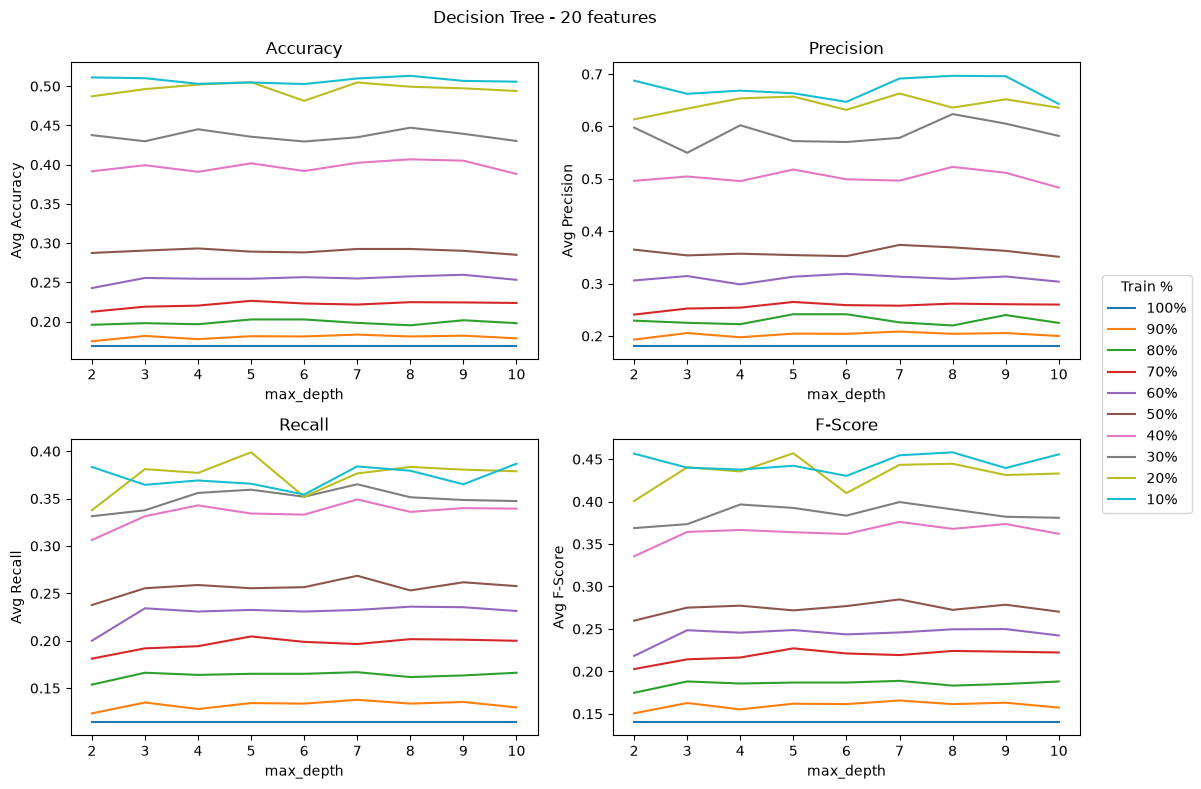

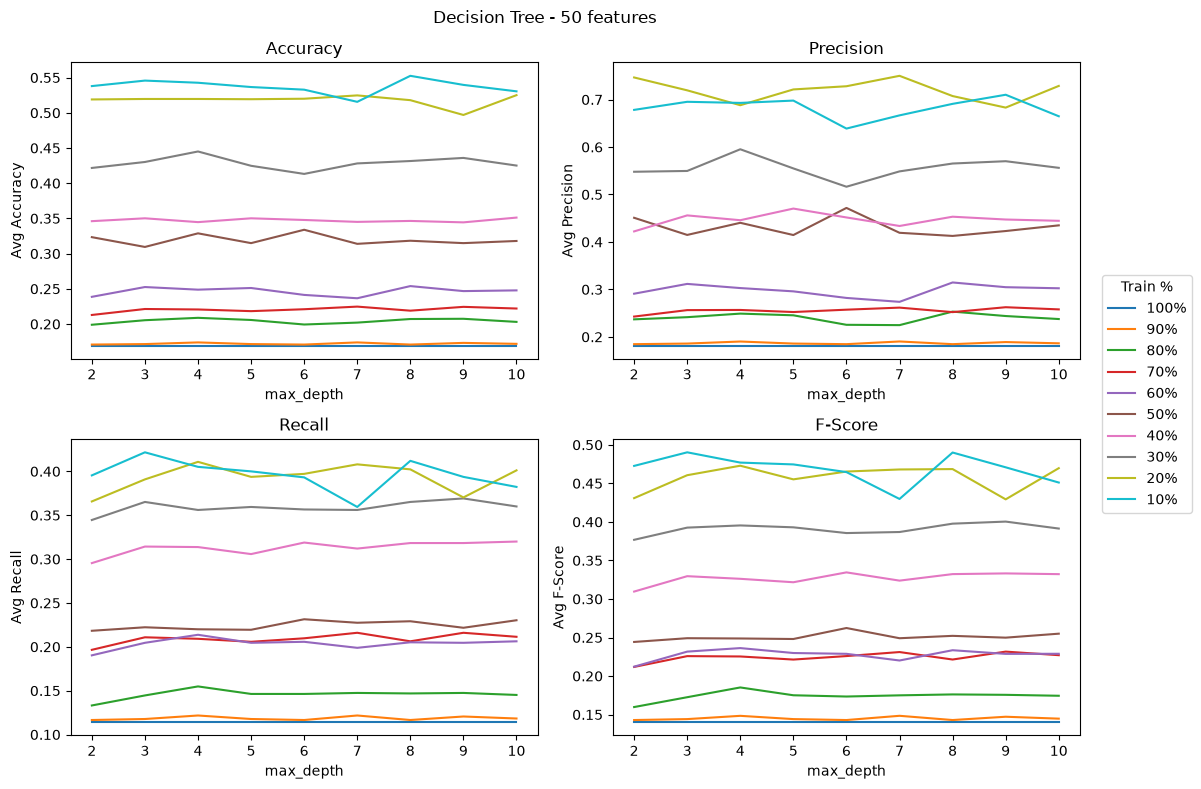

In [26]:
if not COMPLETE:
    for feats, Xtr, Xte in [('20', X20, Xt20), ('50', X50, Xt50)]:
        m, _ = run_tree_sweep(Xtr, Xte, lambda d: DecisionTreeClassifier(max_depth=d), DEPTHS)
        cu.plot_depth_sweep(m, PERCENTS, DEPTHS, 'max_depth', f'Decision Tree - {feats} features')

## Random forest (LOO)

Plots metric vs `max_depth`, one line per training fraction. Trained models are cached.

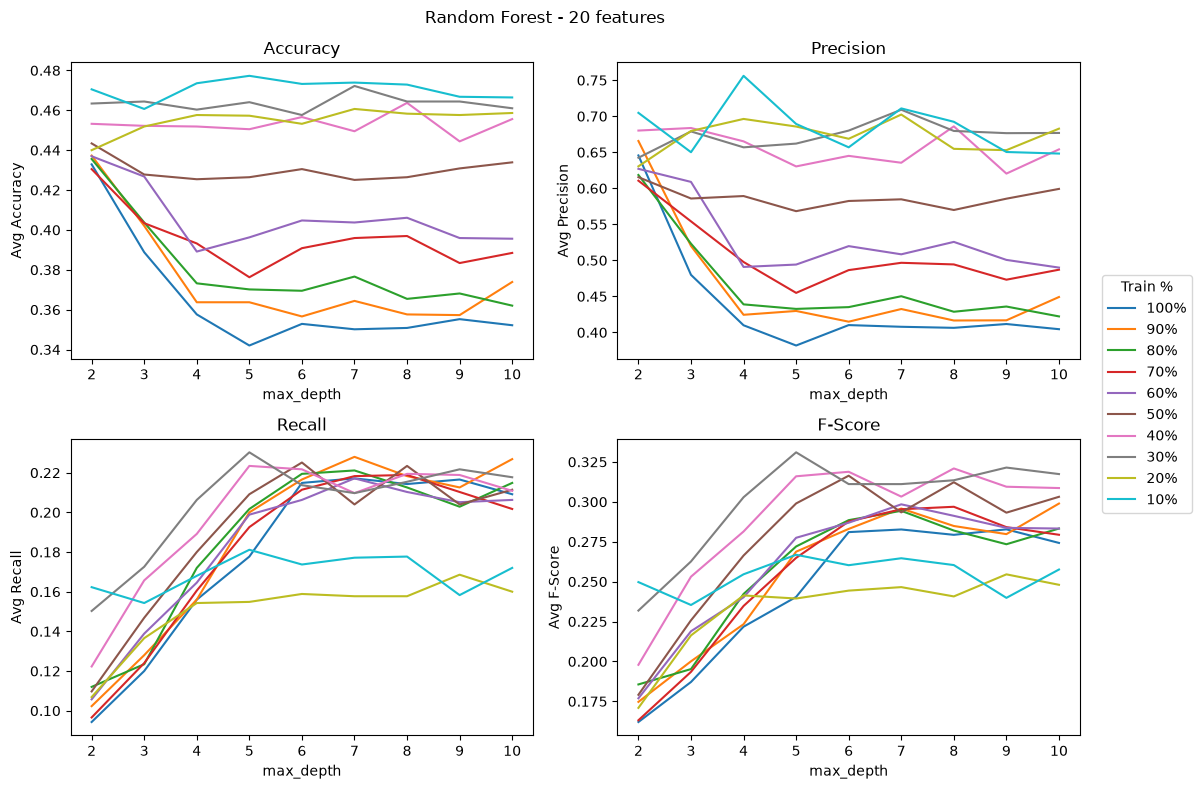

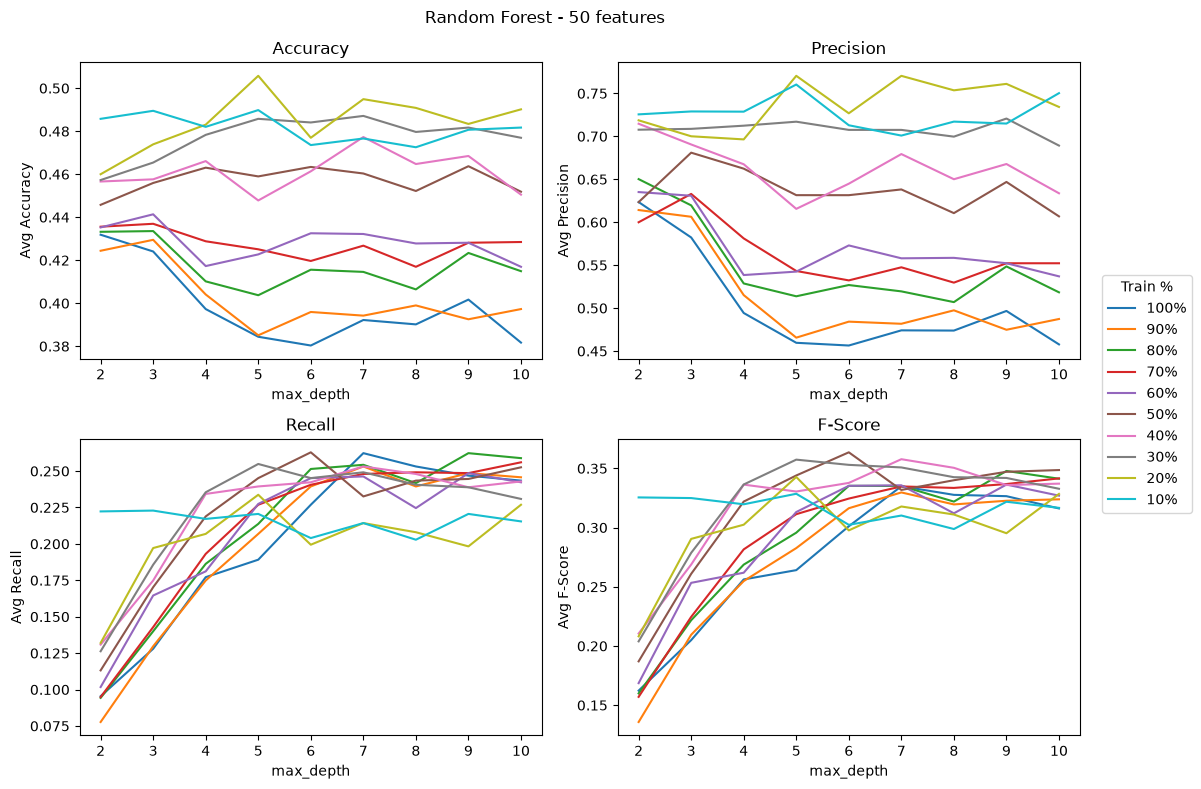

In [27]:
if not COMPLETE:
    for feats, Xtr, Xte in [('20', X20, Xt20), ('50', X50, Xt50)]:
        m, _ = run_tree_sweep(Xtr, Xte, lambda d: RandomForestClassifier(max_depth=d, n_jobs=-1),
                              DEPTHS, cache_sub=f'rf{feats}')
        cu.plot_depth_sweep(m, PERCENTS, DEPTHS, 'max_depth', f'Random Forest - {feats} features')

## XGBoost (LOO)

Plots metric vs `max_depth`, one line per training fraction. Trained models are cached.

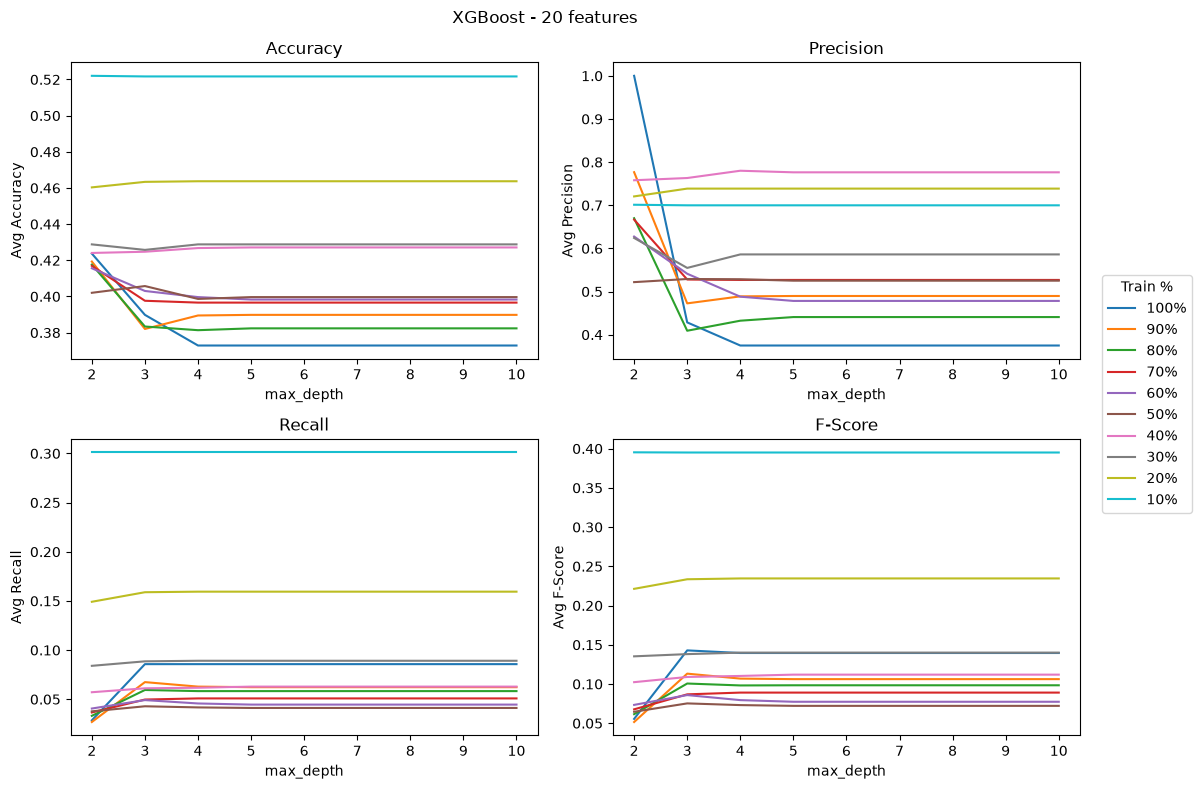

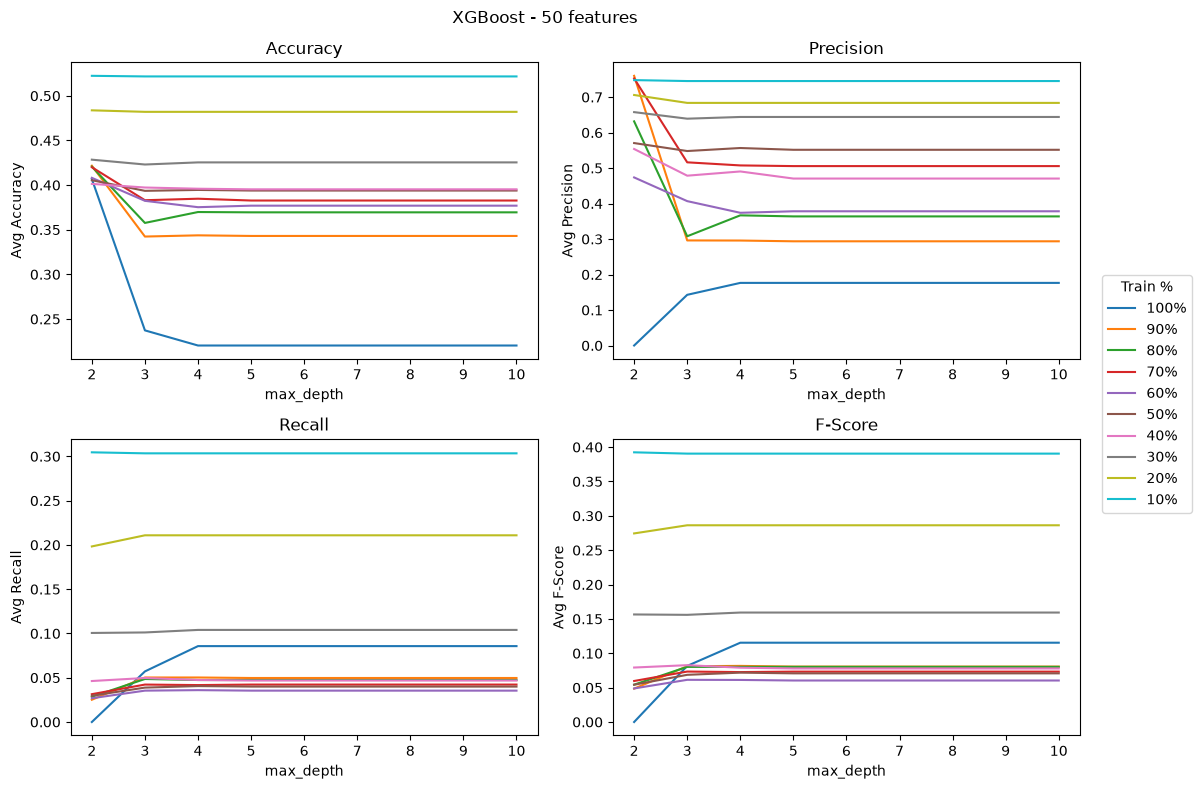

In [28]:
if not COMPLETE:
    for feats, Xtr, Xte in [('20', X20, Xt20), ('50', X50, Xt50)]:
        m, _ = run_tree_sweep(
            Xtr, Xte,
            lambda d: xgb.XGBClassifier(seed=random.randint(-2**31, 2**31 - 1), max_depth=d, n_jobs=-1),
            DEPTHS, cache_sub=f'xgb{feats}')
        cu.plot_depth_sweep(m, PERCENTS, DEPTHS, 'max_depth', f'XGBoost - {feats} features')

## K-nearest neighbors (LOO)

Plots metric vs `k` (neighbor count), one line per training fraction.

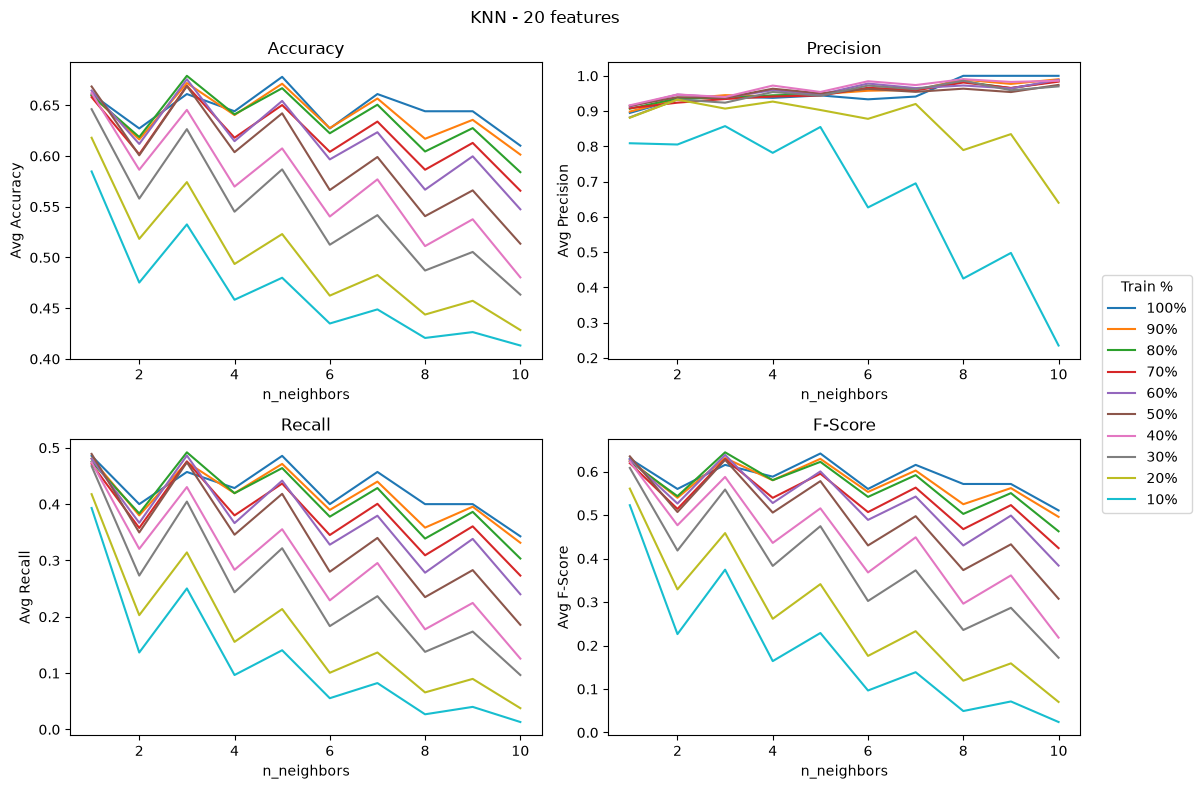

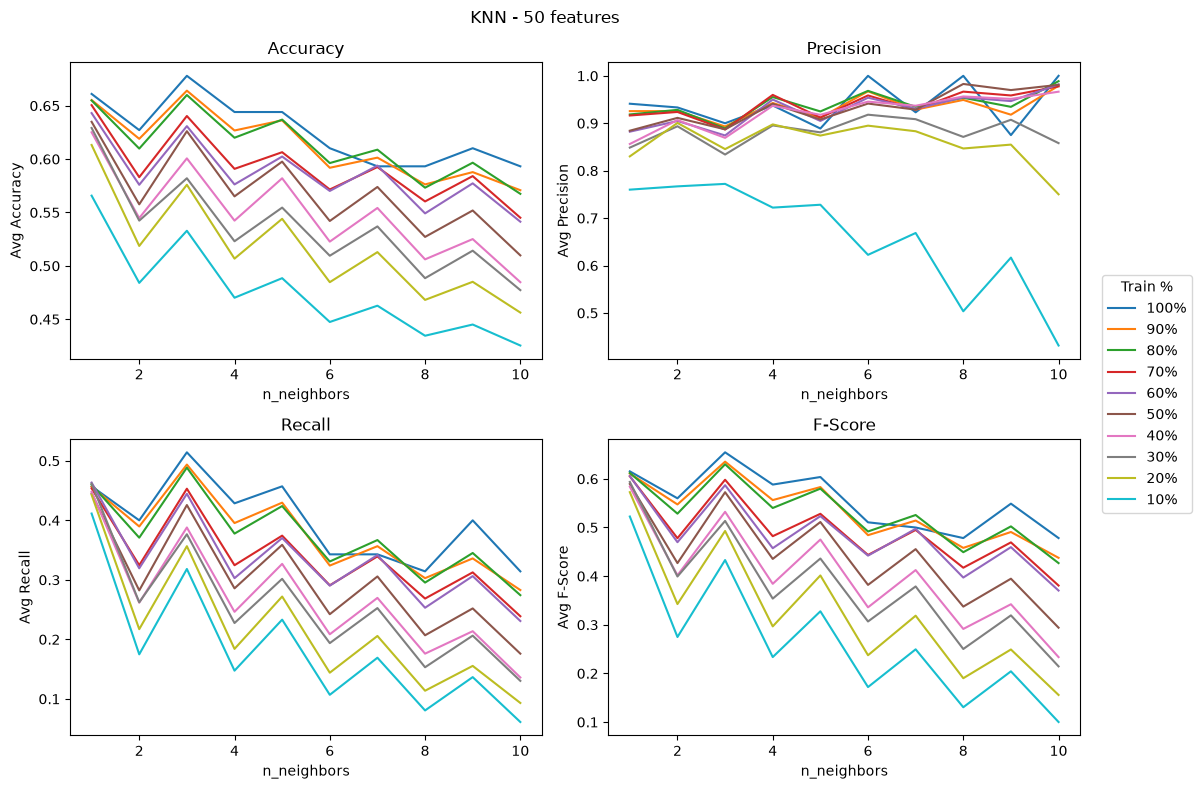

In [29]:
if not COMPLETE:
    for feats, Xtr, Xte in [('20', X20, Xt20), ('50', X50, Xt50)]:
        m, _ = run_tree_sweep(Xtr, Xte, lambda k: KNeighborsClassifier(n_neighbors=k, n_jobs=-1),
                              KS, break_at_full=True)
        cu.plot_depth_sweep(m, PERCENTS, KS, 'n_neighbors', f'KNN - {feats} features')

## Support vector machine (LOO)

The grid search for `(C, gamma)` runs once on the full training set. The best hyperparameters found are reused for every training-size increment and iteration. Displays the best hyperparameters used for the model and plots score vs training fraction, one line per metric.

SVM 20-feat best params: {'C': 1, 'gamma': 0.1}


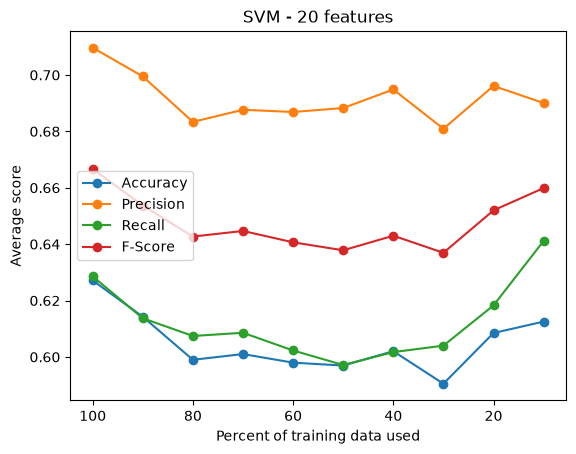

SVM 50-feat best params: {'C': 10, 'gamma': 0.01}


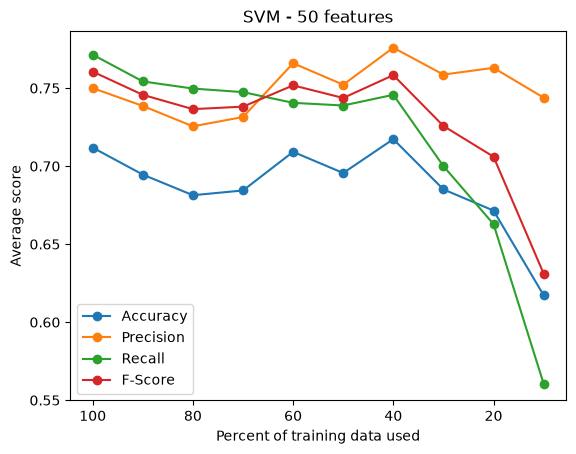

In [30]:
if not COMPLETE:
    def make_svm_fit_predict(Xtr, feats):
        # One grid search on the full training set; reuse (C, gamma) everywhere.
        Xs0 = StandardScaler().fit_transform(Xtr)
        grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [1e-4, 1e-3, 1e-2, 1e-1]}
        best = GridSearchCV(SVC(), grid, cv=3, n_jobs=-1).fit(Xs0, train_labels).best_params_
        print(f'SVM {feats}-feat best params:', best)

        def fit_predict(Xs, ys, Xte, p, it):
            ss = StandardScaler().fit(Xs)
            path = f"pkls/{DIRNAME}/svc{feats}/train_{p*100:.0f}/iter_{it+1}.pkl"
            if os.path.exists(path):
                clf = joblib.load(path)
            else:
                clf = SVC(**best).fit(ss.transform(Xs), ys)
                os.makedirs(os.path.dirname(path), exist_ok=True)
                joblib.dump(clf, path, compress=3)
            return clf.predict(ss.transform(Xte))
        return fit_predict

    for feats, Xtr, Xte in [('20', X20, Xt20), ('50', X50, Xt50)]:
        fp = make_svm_fit_predict(Xtr, feats)
        m, _ = run_increment(Xtr, Xte, fp, break_at_full=True)
        cu.plot_increments(m, PERCENTS, f'SVM - {feats} features')

## Multi-layer perceptron (LOO)

The Keras Tuner search runs once on the full training set. The best hyperparameters and epoch count found are reused at every training-size increment, rather than re-searching each time. Plots score vs training fraction, one line per metric.

Trial 30 Complete [00h 00m 01s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 16s
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

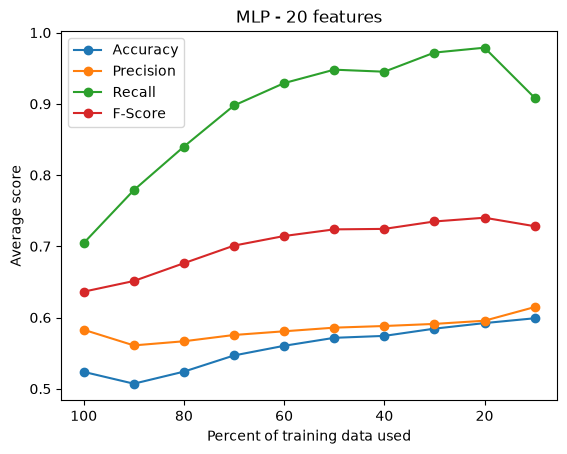

In [31]:
if not COMPLETE:
    from keras.models import load_model

    def make_mlp_fit_predict(Xtr, n_features, feats):
        # One Hyperband search on the full training set; reuse its result per increment.
        ss = StandardScaler().fit(Xtr)
        tuner = kt.Hyperband(make_build_model(n_features), objective='val_accuracy',
                             max_epochs=20, factor=3,
                             directory=f'kt_{DIRNAME}_{feats}', overwrite=False)
        stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
        tuner.search(ss.transform(Xtr), train_labels, epochs=50,
                     validation_split=.2, callbacks=[stop_early])
        best_hps = tuner.get_best_hyperparameters(num_trials=3)[0]
        probe = tuner.hypermodel.build(best_hps)
        hist = probe.fit(ss.transform(Xtr), train_labels, epochs=50, validation_split=.2, verbose=0)
        best_epoch = max(int(np.argmax(hist.history['val_accuracy'])) + 1, 10)

        def fit_predict(Xs, ys, Xte, p, it):
            s = StandardScaler().fit(Xs)
            path = f"pkls/{DIRNAME}/nn{feats}/train_{p*100:.0f}/iter_{it+1}.keras"
            if os.path.exists(path):
                model = load_model(path)
            else:
                model = tuner.hypermodel.build(best_hps)
                model.fit(s.transform(Xs), ys, epochs=best_epoch, validation_split=.2, verbose=0)
                os.makedirs(os.path.dirname(path), exist_ok=True)
                model.save(path)
            return np.round(model.predict(s.transform(Xte))).reshape(-1)
        return fit_predict

    fp = make_mlp_fit_predict(X20, 20, '20')
    m, _ = run_increment(X20, Xt20, fp)
    cu.plot_increments(m, PERCENTS, 'MLP - 20 features')

Trial 30 Complete [00h 00m 01s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 00m 16s
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

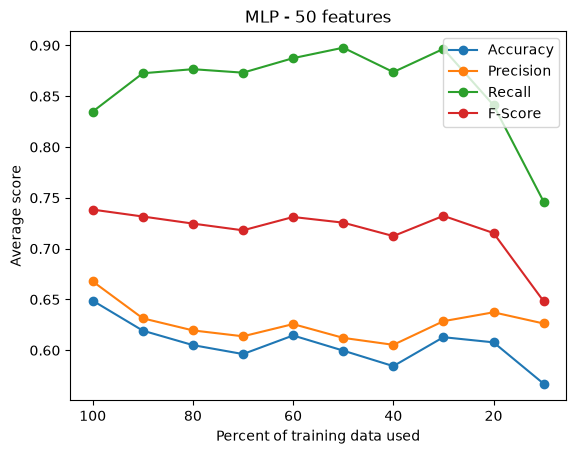

In [32]:
if not COMPLETE:
    fp = make_mlp_fit_predict(X50, 50, '50')
    m, _ = run_increment(X50, Xt50, fp)
    cu.plot_increments(m, PERCENTS, 'MLP - 50 features')

## Logistic regression (LOO)

Features are reduced with an RBF kernel PCA before fitting logistic regression. Plots score vs training fraction, one line per metric.

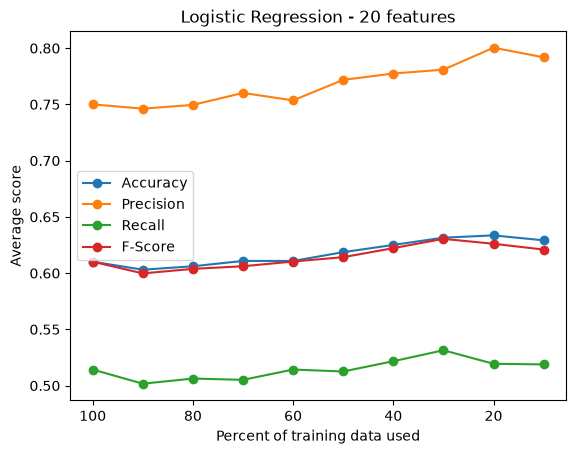

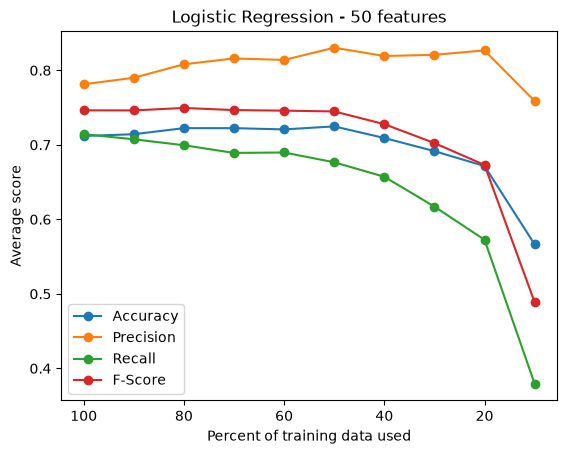

In [33]:
if not COMPLETE:
    def lr_fit_predict(Xs, ys, Xte, p, it):
        ss = StandardScaler()
        nc = min(30, Xs.shape[0])
        kp = KernelPCA(n_components=nc, kernel='rbf')
        Z = kp.fit_transform(ss.fit_transform(Xs))
        clf = LogisticRegression().fit(Z, ys)
        return clf.predict(kp.transform(ss.transform(Xte)))

    for feats, Xtr, Xte in [('20', X20, Xt20), ('50', X50, Xt50)]:
        m, _ = run_increment(Xtr, Xte, lr_fit_predict)
        cu.plot_increments(m, PERCENTS, f'Logistic Regression - {feats} features')